# Dataset overview

How many images fall under each of the four seasons, across the full
processed dataset (train + test).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src import config

In [2]:
# config.CLASSES are the Italian season names used throughout the codebase
# (labels, folder names, config.CLASS_TO_IDX) -- mapped to English here just
# for this figure's axis labels.
SEASON_LABELS_EN = {
    "autunno": "Autumn",
    "estate": "Summer",
    "inverno": "Winter",
    "primavera": "Spring",
}

df = pd.read_csv(config.ANNOTATIONS_PROCESSED)
df = df[df["path_processed"].notna()]

counts = df["class"].value_counts().reindex(config.CLASSES)
counts.index = [SEASON_LABELS_EN[c] for c in counts.index]
counts

Autumn    1305
Summer    1129
Winter    1305
Spring    1181
Name: count, dtype: int64

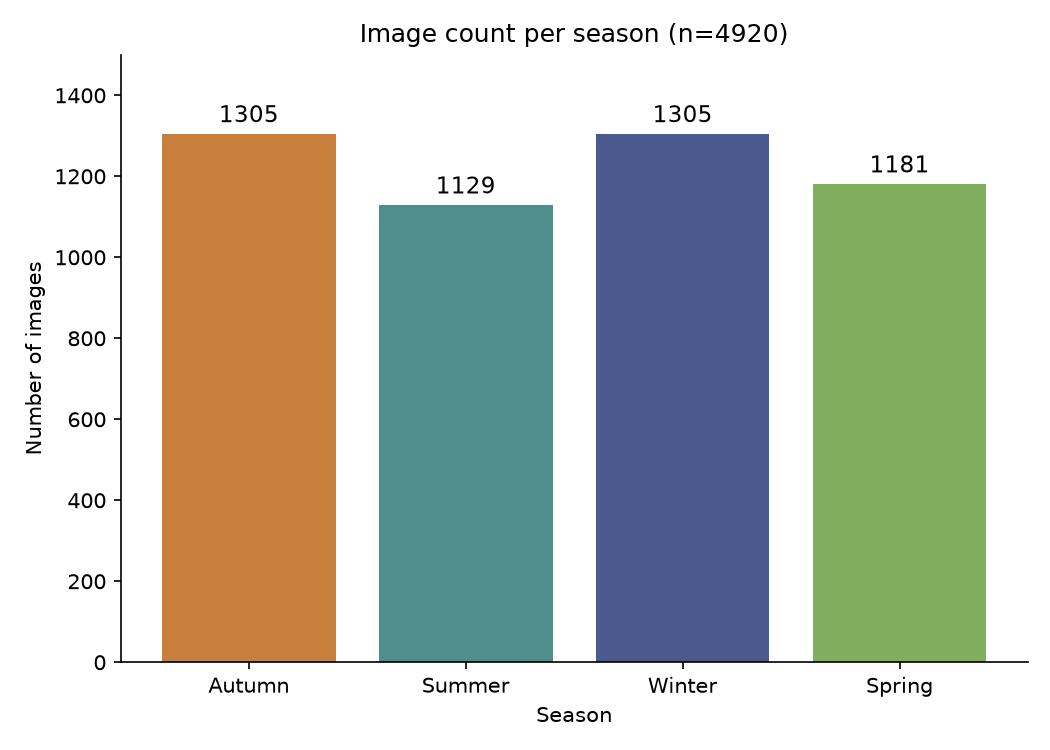

saved to /Users/cheryl.bao/Documents/Projects/Colour-Analysis-using-the-Four-Season-System-via-Deep-Learning/notebooks/figures/class_distribution.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=["#c97f3c", "#4f8f8b", "#4a5a8f", "#7fae5c"])

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, str(count),
            ha="center", va="bottom", fontsize=11)

ax.set_title(f"Image count per season (n={len(df)})")
ax.set_xlabel("Season")
ax.set_ylabel("Number of images")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

out_path = Path.cwd() / "figures" / "class_distribution.png"
out_path.parent.mkdir(exist_ok=True)
plt.savefig(out_path, dpi=150)
plt.show()

print(f"saved to {out_path}")